In [1]:
import pandas as pd
 
df = pd.read_csv('aspirantes_unal.csv')
 
print(f'Filas: {len(df)}, Columnas: {len(df.columns)}')
print(f'Períodos: {df["year"].min()}-{df["semestre"].min()} a {df["year"].max()}-{df["semestre"].max()}')
df.info()


Filas: 556827, Columnas: 16
Períodos: 2019-1 a 2024-2
<class 'pandas.DataFrame'>
RangeIndex: 556827 entries, 0 to 556826
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ins_sede_nombre  556827 non-null  str    
 1   programa         556827 non-null  str    
 2   dep_nac          556827 non-null  str    
 3   sexo             556827 non-null  str    
 4   edad             556827 non-null  int64  
 5   estrato          556827 non-null  str    
 6   tipo_ins         556827 non-null  str    
 7   paes             556827 non-null  str    
 8   ptotal           556827 non-null  float64
 9   admitido         556827 non-null  str    
 10  area_cine        556827 non-null  str    
 11  discapacidad     556827 non-null  str    
 12  nacionalidad     556827 non-null  str    
 13  cods_nac         556827 non-null  str    
 14  year             556827 non-null  int64  
 15  semestre         556827 non-null  int64  


In [2]:
df.describe()


,edad,ptotal,year,semestre
count,556827.000000,556827.000000,556827.000000,556827.000000
mean,19.353146,416.228875,2021.138549,1.298245
std,5.774632,216.534185,1.700035,0.457488
min,-89.000000,-89.000000,2019.000000,1.000000
25%,17.000000,378.973000,2020.000000,1.000000
50%,17.000000,477.423000,2021.000000,1.000000
75%,20.000000,553.174500,2023.000000,2.000000
max,77.000000,1132.194000,2024.000000,2.000000


In [3]:
print(f'Registros con ptotal <= 100: {len(df[df["ptotal"] <= 100])}')
print(f'Registros con edad <= 10: {len(df[df["edad"] <= 10])}')
print(f'Registros con sede "Universidad": {len(df[df["ins_sede_nombre"] == "Universidad"])}')
 
df = df[(df['ptotal'] > 100) & (df['ins_sede_nombre'] != 'Universidad') & (df['edad'] > 10)]
 
print(f'Registros después de limpiar: {len(df)}')


Registros con ptotal <= 100: 89278
Registros con edad <= 10: 395
Registros con sede "Universidad": 17104
Registros después de limpiar: 452456


In [4]:
df.describe()

,edad,ptotal,year,semestre
count,452456.000000,452456.000000,452456.000000,452456.000000
mean,18.155805,504.626978,2021.174852,1.286735
std,2.978096,98.869428,1.703248,0.452237
min,11.000000,110.687000,2019.000000,1.000000
25%,17.000000,438.265000,2020.000000,1.000000
50%,17.000000,504.392000,2021.000000,1.000000
75%,19.000000,569.472000,2023.000000,2.000000
max,74.000000,1132.194000,2024.000000,2.000000


In [5]:
aspirantes_periodo = df.groupby(['year', 'semestre']).size()
 
print('Aspirantes por período:')
print(aspirantes_periodo)

Aspirantes por período:
year  semestre
2019  1           67149
      2           35924
2020  1           55879
      2           28878
2021  1           55654
      2           18921
2022  1           41991
      2           17812
2023  1           52331
      2           28200
2024  1           49717
dtype: int64


In [6]:
tasa_sede = df.groupby('ins_sede_nombre')['admitido'].value_counts(normalize=True)
tasa_sede = tasa_sede.unstack(fill_value=0)
tasa_sede['total'] = df.groupby('ins_sede_nombre')['admitido'].count()
 
print('Tasa de admisión por sede:')
print(tasa_sede.round(3))


Tasa de admisión por sede:
admitido            No     Sí   total
ins_sede_nombre                      
Amazonía         0.769  0.231    6515
Bogotá           0.903  0.097  334943
Caribe           0.544  0.456    1376
De La Paz        0.559  0.441    4711
Manizales        0.562  0.438   15794
Medellín         0.681  0.319   56464
Orinoquía        0.774  0.226   12318
Palmira          0.493  0.507    7270
Tumaco           0.828  0.172   13065


In [7]:
puntaje_periodo = df.groupby(['year', 'semestre'])['ptotal'].agg(['mean', 'median', 'std'])
 
print('Puntaje promedio por período:')
print(puntaje_periodo.round(1))


Puntaje promedio por período:
                mean  median    std
year semestre                      
2019 1         504.8   500.8   99.8
     2         506.2   502.2  100.8
2020 1         506.4   500.5   99.2
     2         519.4   526.2   92.3
2021 1         504.1   511.9   98.4
     2         504.3   513.9   98.1
2022 1         504.2   512.4   98.4
     2         504.0   517.5   98.6
2023 1         500.1   495.2   99.4
     2         500.2   495.8   99.6
2024 1         501.2   493.5   98.9


In [8]:
ext = df[df['cods_nac'] != 'COL']
ext_adm = ext.groupby('cods_nac')['admitido'].value_counts().unstack(fill_value=0)
ext_adm['total'] = ext_adm.sum(axis=1)
ext_adm = ext_adm.sort_values('total', ascending=False).head(20)
 
print('Top 20 nacionalidades extranjeras — admitidos:')
print(ext_adm)


Top 20 nacionalidades extranjeras — admitidos:
admitido    No   Sí  total
cods_nac                  
SUR       2182  507   2689
VEN       1244  275   1519
USA        161   39    200
ESP         93   26    119
ECU         85   21    106
ERI         39   14     53
CRI         33   12     45
COM         37    6     43
PER         27   10     37
BRA         29    7     36
MEX         24    9     33
ITA         22    6     28
KOR         19    9     28
ARG         19    9     28
CYP         22    4     26
PRK         24    2     26
CHL         18    6     24
PAN         17    5     22
CUB         12    7     19
BOL         18    1     19


In [9]:
#Guardar las estadisticas en csv
aspirantes_periodo.to_csv('stats_aspirantes_periodo.csv')
tasa_sede.to_csv('stats_tasa_sede.csv')
puntaje_periodo.to_csv('stats_puntaje_periodo.csv')
ext_adm.to_csv('stats_nacionalidades.csv')

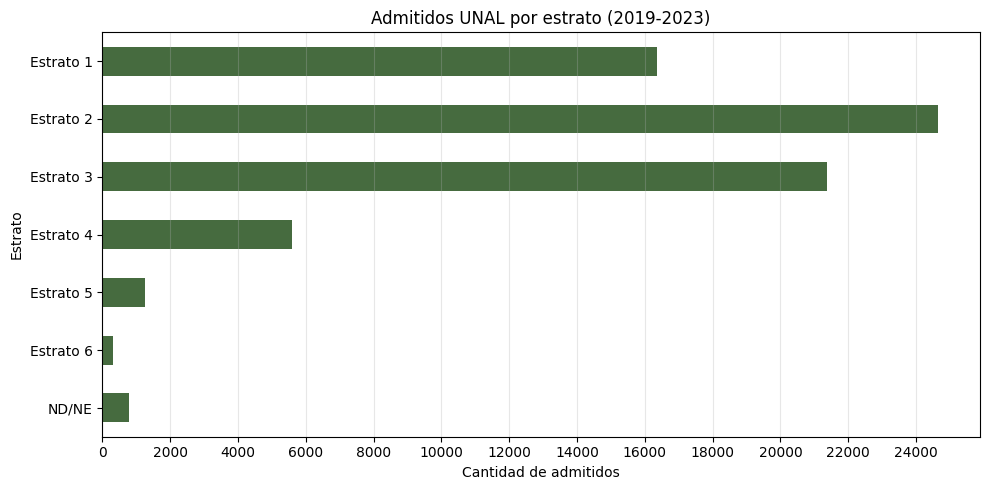

In [10]:
import matplotlib.pyplot as plt
 
admitidos_estrato = df[df['admitido'] == 'Sí']['estrato'].value_counts().sort_index(ascending=False)
 
fig, ax = plt.subplots(figsize=(10, 5))
admitidos_estrato.plot.barh(ax=ax, color='#466B3F')
ax.set_xlabel('Cantidad de admitidos')
ax.set_ylabel('Estrato')
ax.set_title('Admitidos UNAL por estrato (2019-2023)')
ax.grid(axis='x', alpha=0.3)
ax.xaxis.set_major_locator(plt.MultipleLocator(2000))
plt.tight_layout()
plt.savefig('grafica_admitidos_estrato.png', dpi=150)
plt.show()


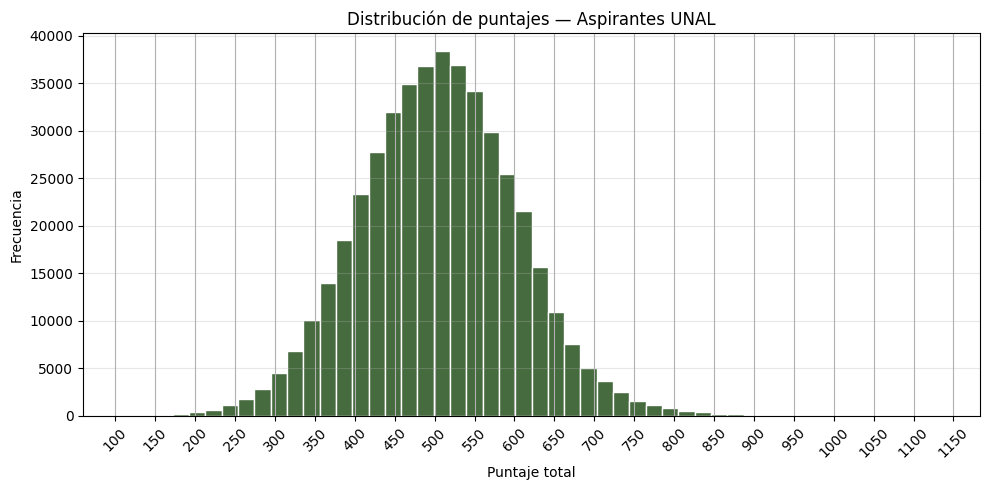

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
df['ptotal'].hist(ax=ax, bins=50, color='#466B3F', edgecolor='white')
ax.set_xlabel('Puntaje total')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de puntajes — Aspirantes UNAL')
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_locator(plt.MultipleLocator(50))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafica_distribucion_puntaje.png', dpi=150)
plt.show()


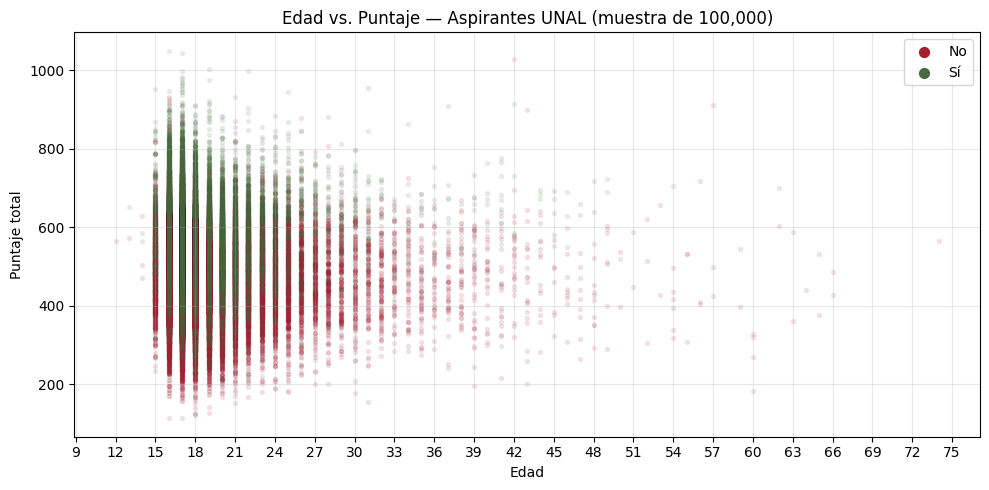

In [12]:
colores = {'Sí': '#466B3F', 'No': '#A61C31'}
 
muestra = df.sample(n=100000, random_state=42)
 
fig, ax = plt.subplots(figsize=(10, 5))
for adm, grupo in muestra.groupby('admitido'):
    ax.scatter(grupo['edad'], grupo['ptotal'], alpha=0.1,
               color=colores[adm], label=adm, s=8)
 
ax.set_xlabel('Edad')
ax.set_ylabel('Puntaje total')
ax.set_title('Edad vs. Puntaje — Aspirantes UNAL (muestra de 100,000)')
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(plt.MultipleLocator(3))
 
legend = ax.legend()
for handle in legend.legend_handles:
    handle.set_alpha(1)
    handle.set_sizes([50])
 
plt.tight_layout()
plt.savefig('grafica_edad_puntaje.png', dpi=150)
plt.show()


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
 
features = pd.get_dummies(df[['edad', 'estrato', 'tipo_ins',
                               'ins_sede_nombre', 'sexo']], drop_first=True)
 
X = features
y = df['ptotal']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42)
 
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
 
print(f'MSE: {mean_squared_error(y_test, y_pred):.1f}')
print(f'R²: {r2_score(y_test, y_pred):.4f}')


MSE: 7994.1
R²: 0.1821
